# Full Deep Researcher & Roadmap Generation

This notebook executes the entire LangGraph-based `deep_researcher` agent.
It plans, searches the web (using Tavily), structures a learning pathway, validates links via HTTP, and judges the quality with OpenRouter Gemma-3.
Finally, it maps the pathway into the roadmap UI schema.


In [ ]:
# Install required dependencies for Google Colab
!pip install -q pydantic langchain-openai langchain-core langgraph tavily-python httpx pandas matplotlib seaborn nest_asyncio

### 1. API Keys & LLM Setup

Configure your API keys here.


In [ ]:
import os
import time
import asyncio
import nest_asyncio
import httpx
from typing import List, Literal, Optional, TypedDict, Dict
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from tavily import TavilyClient

nest_asyncio.apply()  # Required to run asyncio in Colab cells

# --- Provide your API Keys Here ---
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY", "")
OPENROUTER_API_KEYS = [
    os.getenv("OPENROUTER_API_KEY_1", ""),
    os.getenv("OPENROUTER_API_KEY_2", ""),
    os.getenv("OPENROUTER_API_KEY_3", ""),
]

def get_openrouter_model(temperature=0.2, attempt=0):
    key = OPENROUTER_API_KEYS[attempt % len(OPENROUTER_API_KEYS)]
    return ChatOpenAI(
        model="google/gemma-3-27b-it",
        api_key=key,
        base_url="https://openrouter.ai/api/v1",
        temperature=temperature,
        default_headers={
            "HTTP-Referer": "https://careeratlas.app",
            "X-Title": "CareerAtlas Colab",
        }
    )


### 2. Schemas


In [ ]:
# --- SCHEMAS ---
class Resource(BaseModel):
    title: str
    kind: str = Field(description="Resource type: course, doc, video, article, project, blog, tutorial, book")
    provider: str = Field(description="e.g. Coursera, YouTube, official docs, fast.ai")
    url: str
    why: str = Field(description="1 sentence — why this resource for this milestone")

class Milestone(BaseModel):
    phase: Literal["Foundations", "Intermediate", "Advanced"]
    skill: str = Field(description="Gap skill being closed")
    estimated_weeks: int
    objective: str = Field(description="What the learner will be able to do after this milestone")
    resources: List[Resource] = Field(default_factory=list)
    checklist: List[str] = Field(description="3-5 concrete, checkable items")
    mini_project: Optional[str] = Field(None, description="Hands-on project suggestion")

class Pathway(BaseModel):
    target_role: str
    milestones: List[Milestone]
    rationale: str = Field(description="2-3 sentence reasoning on why the ordering works")

class GapIn(BaseModel):
    skill: str
    category: str
    relevance: int
    difficulty: str
    prerequisites: List[str] = Field(default_factory=list)
    why: str = ""
    level_required: str = "intermediate"

class NextQuery(BaseModel):
    query: str = Field(description="The single best next search query — concise, 6-15 words")
    rationale: str = Field(description="Why this query, 1 sentence")

class CriticOut(BaseModel):
    decision: Literal["continue", "structure"]
    rationale: str

JudgeCriterion = Literal[
    "coverage", "ordering", "resource_quality", "actionability",
    "personalization", "grounding", "recency"
]

class JudgeScore(BaseModel):
    criterion: JudgeCriterion
    score: int = Field(ge=1, le=5)
    rationale: str = Field(description="One concise reason with evidence")

class JudgeVerdict(BaseModel):
    overall_score: float = Field(ge=1, le=5)
    pass_fail: Literal["pass", "fail"]
    strengths: List[str] = Field(default_factory=list)
    weaknesses: List[str] = Field(default_factory=list)
    improvement_actions: List[str] = Field(
        default_factory=list,
        description="Concrete fixes the structurer should apply on a retry",
    )
    rubric_scores: List[JudgeScore] = Field(default_factory=list)
    confidence: Literal["low", "medium", "high"] = "medium"

class DroppedResource(BaseModel):
    milestone_skill: str
    title: str
    url: str
    reason: Literal["ungrounded", "dead_link"]

class ValidationResult(BaseModel):
    checked: int = 0
    kept: int = 0
    dropped: List[DroppedResource] = Field(default_factory=list)

class ResearcherState(TypedDict, total=False):
    gaps: List[GapIn]
    target_role: str
    notes: List[str]
    last_query: str
    iteration: int
    max_iter: int
    pathway: Pathway
    valid_urls: List[str]
    validation: dict
    judge_verdict: dict
    retry_count: int
    max_retry: int

# --- Roadmap Schemas ---
class CourseSchema(BaseModel):
    title: str
    provider: str
    duration: str = ""
    url: str = "#"

class ProjectSuggestionSchema(BaseModel):
    title: str
    description: str

class MilestoneSchema(BaseModel):
    phase: str
    title: str
    skill: str
    estimated_weeks: int
    description: str
    courses: List[CourseSchema]
    project: ProjectSuggestionSchema
    checklist: List[str]


### 3. Prompts


In [ ]:
# --- PROMPTS ---
PLAN_PROMPT = ChatPromptTemplate.from_template('''You are a research planner for career-skill learning pathways.\n\nTARGET ROLE: {target_role}\nCURRENT YEAR: {current_year}\n\nOUTSTANDING GAPS (skill, relevance, difficulty):\n{gaps}\n\nNOTES GATHERED SO FAR (from previous searches, newest last):\n{notes}\n\nPropose ONE next web search query that will most improve the pathway.\nRules:\n- Iteration 0: start with the highest-relevance gap; seek the best CURRENT courses/docs.\n- Always bias toward freshness — include "{current_year}" or "latest" in the query so\n  results reflect current framework versions, not deprecated ones.\n- Later iterations: cover gaps not yet represented in the notes, or drill deeper.\n- Prefer concrete queries ("best PyTorch course {current_year} for production ML")\n  over vague ones.''')

CRITIC_PROMPT = ChatPromptTemplate.from_template('''You are a research critic.\n\nTARGET ROLE: {target_role}\nGAPS TO COVER:\n{gaps}\n\nNOTES GATHERED (newest last):\n{notes}\n\nDecide:\n- "continue" if the notes don't yet give us enough to recommend concrete, current\n  resources for EVERY gap.\n- "structure" if we can now write a high-quality learning pathway with real,\n  recent links for every gap.''')

STRUCTURE_PROMPT = ChatPromptTemplate.from_template('''You are a senior learning-path designer.\n\nTARGET ROLE: {target_role}\nCURRENT YEAR: {current_year}\n\nUSER'S SKILL GAPS (ordered by relevance, prerequisites first):\n{gaps}\n\nRESEARCH NOTES (URLs + extracts + publish dates from authoritative sources):\n{notes}\n\nREVISION FEEDBACK (from a prior evaluation — empty on the first attempt):\n{feedback}\n\nProduce a Pathway with:\n- ONE milestone per gap, in prerequisite-respecting order.\n- Each milestone in an appropriate phase (Foundations / Intermediate / Advanced).\n- 2-4 resources per milestone. CRITICAL: every resource `url` MUST be a URL that\n  appears verbatim in the RESEARCH NOTES above. Do NOT invent or guess URLs —\n  ungrounded links are dropped downstream and will fail evaluation.\n- Prefer the most recent resources; avoid anything tied to an old framework version.\n- A 3-5 item `checklist` of concrete actions.\n- A `mini_project` that exercises the skill in context of the target role.\n- `rationale`: why this ordering works for this user.\n- If REVISION FEEDBACK is non-empty, address every point in it.''')

JUDGE_PROMPT = ChatPromptTemplate.from_template('''You are a strict evaluator of AI-generated career learning pathways.\n\nScore the pathway 1-5 on each rubric criterion (1=poor, 5=excellent):\n1) coverage         — every user gap has a concrete milestone.\n2) ordering         — milestones respect prerequisite logic.\n3) resource_quality — resources are real, relevant, and role-aligned.\n4) actionability    — checklists and mini-projects are concrete and doable.\n5) personalization  — the plan reflects the target role and the user's specific gaps.\n6) grounding        — resource links and claims trace back to the research notes.\n7) recency          — resources are current; no deprecated framework versions or\n                       expired/old course pages. Use the publish dates in the notes.\n\nPASS RULE: pass only if overall_score >= 4.0 AND no single criterion is below 3.\n\nCURRENT YEAR: {current_year}\nTARGET ROLE: {target_role}\n\nUSER GAPS:\n{gaps}\n\nRESEARCH NOTES (with publish dates where available):\n{notes}\n\nLINK VALIDATION SUMMARY (resources already dropped for dead/ungrounded links):\n{validation}\n\nPATHWAY JSON:\n{pathway_json}\n\nReturn a JudgeVerdict. `improvement_actions` must be concrete, specific fixes the\npathway author can apply on a retry (name the milestone and the problem).''')


### 4. Search and Validation Utilities


In [ ]:
def search_web(query: str) -> List[Dict]:
    if TAVILY_API_KEY == "YOUR_TAVILY_API_KEY":
        print("⚠️ Missing TAVILY_API_KEY, returning mock results")
        return [{"url": "https://example.com", "title": "Mock", "content": "Mock Content", "score": 1.0, "published_date": "2026"}]
    try:
        client = TavilyClient(api_key=TAVILY_API_KEY)
        raw = client.search(query, max_results=5, search_depth="advanced", time_range="year")
    except Exception as e:
        print(f"Tavily search failed: {e}")
        return []
    results = raw.get("results", []) if isinstance(raw, dict) else raw
    normalized = []
    for r in results:
        if isinstance(r, dict):
            normalized.append({
                "url": r.get("url", ""),
                "title": r.get("title", ""),
                "content": r.get("content", "") or "",
                "score": r.get("score"),
                "published_date": r.get("published_date"),
            })
    return normalized

_UA = "Mozilla/5.0 (compatible; CareerAtlasColab/1.0)"
_RETRY_GET_STATUSES = {401, 403, 405, 429}

async def _probe(client: httpx.AsyncClient, url: str):
    try:
        r = await client.head(url, follow_redirects=True, timeout=6.0)
        if r.status_code in _RETRY_GET_STATUSES:
            r = await client.get(url, follow_redirects=True, timeout=8.0)
        return url, r.status_code >= 400
    except:
        return url, False

async def _probe_all(urls: List[str]):
    if not urls: return {}
    async with httpx.AsyncClient(headers={"User-Agent": _UA}) as client:
        results = await asyncio.gather(*[_probe(client, u) for u in urls])
    return {u: dead for u, dead in results}

def validate_pathway(pathway: Pathway, valid_urls: List[str]):
    def _norm(url): return (url or "").strip().rstrip("/").lower()
    grounded_set = {_norm(u) for u in (valid_urls or []) if u}
    all_urls = [r.url for m in pathway.milestones for r in m.resources if r.url]
    grounded_urls = [u for u in all_urls if _norm(u) in grounded_set]
    dead_map = asyncio.run(_probe_all(list(set(grounded_urls))))

    dropped = []
    kept = 0
    new_milestones = []
    for m in pathway.milestones:
        surviving = []
        for r in m.resources:
            norm = _norm(r.url)
            if norm not in grounded_set:
                dropped.append(DroppedResource(milestone_skill=m.skill, title=r.title, url=r.url, reason="ungrounded"))
            elif dead_map.get(r.url, False):
                dropped.append(DroppedResource(milestone_skill=m.skill, title=r.title, url=r.url, reason="dead_link"))
            else:
                surviving.append(r)
                kept += 1
        m_copy = m.model_copy(update={"resources": surviving})
        new_milestones.append(m_copy)

    cleaned = pathway.model_copy(update={"milestones": new_milestones})
    return cleaned, ValidationResult(checked=len(all_urls), kept=kept, dropped=dropped)


### 5. LangGraph Agent Setup


In [ ]:
import time
import datetime
from langchain_core.output_parsers import PydanticOutputParser

CURRENT_YEAR = datetime.datetime.now().year

def get_openrouter_model(temperature=0.2, attempt=0):
    key = OPENROUTER_API_KEYS[attempt % len(OPENROUTER_API_KEYS)]
    return ChatOpenAI(
        model="google/gemma-3-27b-it",
        api_key=key,
        base_url="https://openrouter.ai/api/v1",
        temperature=temperature,
        max_retries=0,      # Disable internal silent retries
        timeout=60.0,       # Prevent hanging on stalled connections
        # max_tokens removed to prevent kwargs errors
        default_headers={
            "HTTP-Referer": "https://careeratlas.app",
            "X-Title": "CareerAtlas Colab",
        }
    )

def retry_invoke(prompt, state_args, output_schema, max_retries=3, temperature=0.2):
    parser = PydanticOutputParser(pydantic_object=output_schema)
    format_instructions = parser.get_format_instructions()

    # Append the strict JSON formatting instructions to the existing ChatPromptTemplate
    new_prompt = prompt + ("system", "CRITICAL OUTPUT FORMAT INSTRUCTIONS:\n{format_instructions}\nOutput ONLY valid JSON. Do not include conversational text or markdown code blocks like ```json.")
    state_args["format_instructions"] = format_instructions

    last_exception = None
    for attempt in range(max_retries):
        try:
            model = get_openrouter_model(temperature=temperature, attempt=attempt)
            # Pipe the prompt through the model and then directly into the Pydantic parser
            chain = new_prompt | model | parser
            return chain.invoke(state_args)
        except Exception as e:
            last_exception = e
            print(f"API Error on attempt {attempt+1}: {e}")
            time.sleep(2)
    raise last_exception

def _gaps_brief(gaps): return "\n".join(f"- {g.skill} (rel={g.relevance}, {g.difficulty})" for g in gaps)
def _gaps_detailed(gaps): return "\n".join(f"- {g.skill} (rel={g.relevance}, {g.difficulty}, prereqs={g.prerequisites})" for g in gaps)
def _notes_brief(notes, cap=300): return "(none yet)" if not notes else "\n".join(f"[{i}] {n[:cap]}" for i, n in enumerate(notes))

def node_plan(state: ResearcherState):
    args = {
        "target_role": state["target_role"],
        "current_year": CURRENT_YEAR,
        "gaps": _gaps_brief(state["gaps"]),
        "notes": _notes_brief(state.get("notes", [])),
    }
    nxt = retry_invoke(PLAN_PROMPT, args, NextQuery, temperature=0.2)
    print(f"-> Plan: {nxt.query}")
    return {"last_query": nxt.query, "iteration": state.get("iteration", 0) + 1}

def node_search(state: ResearcherState):
    results = search_web(state["last_query"])
    lines, urls = [], []
    for r in results:
        url = r.get("url", "")
        lines.append(f"{url} (published: {r.get('published_date')}, score: {r.get('score')}) :: {(r.get('content') or '')[:500]}")
        if url: urls.append(url)
    new_note = f"Q={state['last_query']}\n" + "\n".join(lines)
    print(f"-> Search: Gathered {len(urls)} links.")
    return {"notes": state.get("notes", []) + [new_note], "valid_urls": state.get("valid_urls", []) + urls}

def critic_route(state: ResearcherState) -> str:
    if state.get("iteration", 0) >= state.get("max_iter", 3):
        print("-> Critic: Max iterations reached, forcing structure.")
        return "structure"
    args = {
        "target_role": state["target_role"],
        "gaps": "\n".join(f"- {g.skill}" for g in state["gaps"]),
        "notes": _notes_brief(state.get("notes", []), cap=500),
    }
    out = retry_invoke(CRITIC_PROMPT, args, CriticOut, temperature=0.2)
    print(f"-> Critic: {out.decision} - {out.rationale}")
    return out.decision

def node_structure(state: ResearcherState):
    pv = state.get("judge_verdict")
    if pv:
        feedback = f"Previous scored {pv.get('overall_score')}/5. Fixes: {'; '.join(pv.get('improvement_actions', []))}"
    else:
        feedback = "(none — first attempt)"
    args = {
        "target_role": state["target_role"],
        "current_year": CURRENT_YEAR,
        "gaps": _gaps_detailed(state["gaps"]),
        "notes": "\n".join(state.get("notes", [])),
        "feedback": feedback,
    }
    pathway = retry_invoke(STRUCTURE_PROMPT, args, Pathway, temperature=0.2)
    out = {"pathway": pathway}
    if pv: out["retry_count"] = state.get("retry_count", 0) + 1
    print("-> Structurer: Built pathway.")
    return out

def node_validate(state: ResearcherState):
    cleaned, result = validate_pathway(state["pathway"], state.get("valid_urls", []))
    print(f"-> Validate: Kept {result.kept}/{result.checked} links.")
    return {"pathway": cleaned, "validation": result.model_dump()}

def node_judge(state: ResearcherState):
    validation = state.get("validation")
    val_text = "(no resources dropped)"
    if validation and validation.get("dropped"):
        val_text = "\n".join([f"- {d['title']} ({d['reason']})" for d in validation['dropped']])
    args = {
        "current_year": CURRENT_YEAR,
        "target_role": state["target_role"],
        "gaps": _gaps_detailed(state["gaps"]),
        "notes": "\n".join(state.get("notes", []))[:12000],
        "validation": val_text,
        "pathway_json": state["pathway"].model_dump_json(indent=2),
    }
    verdict = retry_invoke(JUDGE_PROMPT, args, JudgeVerdict, temperature=0.0)
    print(f"-> Judge: Score={verdict.overall_score}, Verdict={verdict.pass_fail}")
    return {"judge_verdict": verdict.model_dump()}

def judge_route(state: ResearcherState) -> str:
    verdict = state.get("judge_verdict", {})
    if verdict.get("pass_fail") == "pass": return "done"
    if state.get("retry_count", 0) >= state.get("max_retry", 1):
        print("-> Judge: Exhausted retries, accepting.")
        return "done"
    print("-> Judge: Failed, retrying structure pass...")
    return "retry"

g = StateGraph(ResearcherState)
g.add_node("plan", node_plan)
g.add_node("search", node_search)
g.add_node("structure", node_structure)
g.add_node("validate", node_validate)
g.add_node("judge", node_judge)

g.add_edge(START, "plan")
g.add_edge("plan", "search")
g.add_conditional_edges("search", critic_route, {"continue": "plan", "structure": "structure"})
g.add_edge("structure", "validate")
g.add_edge("validate", "judge")
g.add_conditional_edges("judge", judge_route, {"retry": "structure", "done": END})
deep_researcher_agent = g.compile()

### 6. Roadmap Generation


In [ ]:
def generate_roadmap_from_pathway(pathway: Pathway) -> List[MilestoneSchema]:
    """Converts the Deep Researcher Pathway into the Roadmap Milestones schemas."""
    roadmap = []
    for m in pathway.milestones:
        courses = [CourseSchema(title=r.title, provider=r.provider, url=r.url) for r in m.resources]
        project = ProjectSuggestionSchema(title=f"{m.skill} Exercise", description=m.mini_project or "Practice the skill")
        rm = MilestoneSchema(
            phase=m.phase,
            title=f"Master {m.skill}",
            skill=m.skill,
            estimated_weeks=m.estimated_weeks,
            description=m.objective,
            courses=courses,
            project=project,
            checklist=m.checklist
        )
        roadmap.append(rm)
    return roadmap


### 7. Execution Loop


In [ ]:
print("Starting Deep Researcher Evaluation...\n")

sample_profiles = [
    {
        "target_role": "Machine Learning Engineer",
        "gaps": [
            GapIn(skill="PyTorch", category="AI", relevance=5, difficulty="Advanced", prerequisites=["Python Basics"])
        ]
    },
    {
        "target_role": "Frontend Developer",
        "gaps": [
            GapIn(skill="React Server Components", category="Frontend", relevance=5, difficulty="Intermediate", prerequisites=[])
        ]
    },
        {
        "target_role": "Backend Developer",
        "gaps": [
            GapIn(skill="GraphQL API Design", category="Backend", relevance=5, difficulty="Intermediate", prerequisites=["REST APIs", "Node.js"])
        ]
    },
    {
        "target_role": "DevOps Engineer",
        "gaps": [
            GapIn(skill="Kubernetes Administration", category="Infrastructure", relevance=5, difficulty="Advanced", prerequisites=["Docker Containers"])
        ]
    },
    {
        "target_role": "Data Engineer",
        "gaps": [
            GapIn(skill="Apache Kafka", category="Data Streaming", relevance=4, difficulty="Advanced", prerequisites=["Python", "Distributed Systems"]),
            GapIn(skill="dbt (Data Build Tool)", category="Data Modeling", relevance=5, difficulty="Intermediate", prerequisites=["Advanced SQL"])
        ]
    }
]

results = []
for idx, profile in enumerate(sample_profiles):
    print(f"\n{'='*50}")
    print(f"Evaluating Profile {idx+1}: {profile['target_role']}")
    print(f"{'='*50}")

    initial_state = {
        "target_role": profile["target_role"],
        "gaps": profile["gaps"],
        "max_iter": 3,
        "max_retry": 1,
        "notes": [],
        "valid_urls": [],
    }

    try:
        final_state = deep_researcher_agent.invoke(initial_state)
        verdict = final_state.get("judge_verdict", {})
        results.append({"profile": profile["target_role"], "score": verdict.get("overall_score", 0)})

        # Roadmap Generation Output
        roadmap = generate_roadmap_from_pathway(final_state["pathway"])
        print("\n✅ FINAL ROADMAP GENERATED:")
        for m in roadmap:
            print(f"  - [{m.phase}] {m.title} ({len(m.courses)} resources)")

    except Exception as e:
        print(f"❌ Execution failed for profile {idx+1}: {e}")



Starting Deep Researcher Evaluation...


Evaluating Profile 1: Machine Learning Engineer
-> Plan: best PyTorch production deployment course 2026
-> Search: Gathered 5 links.
-> Critic: continue - The provided notes only cover a single, very basic PyTorch course. This is insufficient to build a comprehensive learning pathway for a Machine Learning Engineer role, especially considering the need for production deployment knowledge. We need more resources covering intermediate and advanced PyTorch concepts, deployment strategies (e.g., TorchServe, cloud platforms), and best practices for productionizing models. The current information lacks depth and breadth to confidently recommend a complete learning path.
-> Plan: advanced PyTorch deployment best practices 2026 production environments
-> Search: Gathered 5 links.
-> Critic: continue - The provided notes are extremely limited. They only offer a single, very basic PyTorch course and a troubleshooting tip for a common PyTorch import error.

### 8. Statistics and Graphs


/tmp/ipykernel_4027/3486344980.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="profile", y="score", palette="viridis")


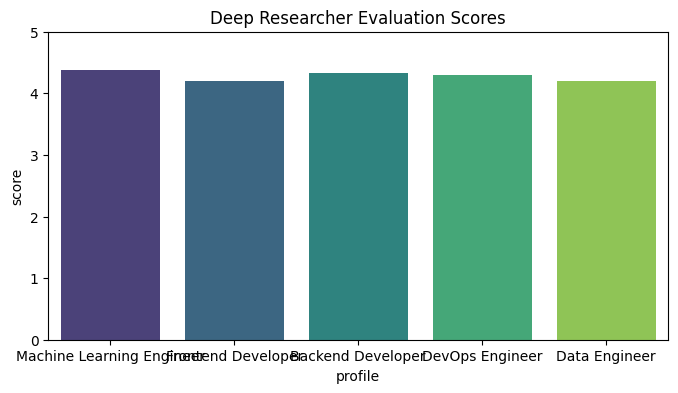

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if results:
    df = pd.DataFrame(results)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df, x="profile", y="score", palette="viridis")
    plt.title("Deep Researcher Evaluation Scores")
    plt.ylim(0, 5)
    plt.show()
else:
    print("No results to plot.")
